<a href="https://colab.research.google.com/github/gitnicolas343/intro_neurociencias_Computacionesles_phyton/blob/main/BRAIN_DYNAMICS_SIMULATION_OF_SCHIZOPHREMIA_WITH_CHAOTIC_NEURAL_NETWORKS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install h5py --quiet   #libreria para importar los datos usados en el articulo
!pip install numba --quiet  #optimizacion de tiempos
!pip install networkx --quiet  #analizis de los grafos

In [ ]:
#generales
import h5py
import numpy as np
import matplotlib.pyplot as plt

#especificas
from numba import njit
from scipy.interpolate import interp1d
from scipy.stats import ttest_ind
import networkx as nx

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# INTRODUCCIÓN

---

El cerebro se divide en múltiples regiones cerebrales interconectadas por tractos de materia blanca que forman una red compleja. Sus estructuras topológicas son importantes para la integración de información, manifestándose como **dinámicas no lineales complejas**. Gracias a técnicas no invasivas, ha sido posible establecer asociaciones entre las estructuras de las regiones cerebrales y múltiples trastornos psiquiátricos. En particular, la esquizofrenia (EQZ) es un trastorno asociado a anomalías cerebrales en los pacientes, derivadas de una red cerebral de conectividad alterada.

* La organización estructural de las redes cerebrales está alterada en la EQZ (topología aberrante).
* Las redes cerebrales muestran mayor *clustering* (agrupación local).
* Menor longitud de camino característica (caminos más largos entre regiones).
* Menor eficiencia global (peor transmisión de información en toda la red).
* Estas zonas presentan menor eficiencia y mayor longitud de camino.

Es difícil determinar qué actividades conducen a una red cerebral anómala, ya que estas anomalías exhiben gran diversidad. Solo mediante el análisis de métricas de teoría de grafos, la EQZ puede describirse como una desconectividad cerebral distribuida. En el estado del arte se ha propuesto que los desequilibrios en la relación excitación-inhibición podrían explicar las redes funcionales anómalas observadas en la EQZ. Aunque el modelado cerebral completo es una herramienta útil, aún faltan estudios detallados a nivel regional. Por ello, este trabajo explora cómo la estructura de la red cerebral se relaciona con las oscilaciones beta anómalas en la EQZ.

Para tal fin, se introdujo el modelo de red neuronal caótica de Aihara (CNN), reconocido por su base electrofisiológica y su capacidad para generar dinámicas complejas ajustables entre estados estables, caóticos y críticos.




# METODOS

---


El estudio utilizó un conjunto de datos (adjunto) que incluye imágenes cerebrales de 27 individuos con esquizofrenia y 27 controles sanos, obtenidas mediante resonancia magnética de 3 Tesla. El cerebro se dividió en 83 regiones corticales y subcorticales como se muestra:

datos: (https://zenodo.org/records/3758534)


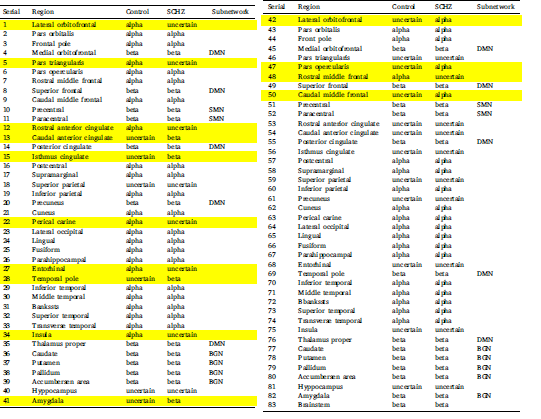


In [ ]:
#carga de datos
datos = '/content/drive/Shareddrives/Neuro Ciencias/NEURO CIENCIAS/datos_articulo/27_SCHZ_CTRL_dataset.mat'


f =  h5py.File(datos, 'r')

# navegacion por la base de datos
ctrl_grp = f["SC_FC_Connectomes"]["SC_density"]["ctrl"]
schz_grp = f["SC_FC_Connectomes"]["SC_density"]["schz"]

control_matrix = list()                       # extrigo los arreglos contenidos en la estrutura de datos
schizo_matrix = list()


for ref in ctrl_grp:                          #es un arreglo de arreglos por lo que ref son los datos de interes
    control_matrix.append(f[ref[0]][:])
for ref in schz_grp:
    schizo_matrix.append(f[ref[0]][:])


wij_ctrl_1 = control_matrix[0]                  #el primer elemento parece tener los datos de las 83 regiones de concetividad cerebral
wij_schizo_1 = schizo_matrix[0]                 #debido a su forma


wij_ctrl = np.mean(wij_ctrl_1, axis=0)         #dado que son 27 sujetos, pensamos que podemos promediar fines ilustrativos
wij_schizo = np.mean(wij_schizo_1, axis=0)

#para efectos de las graficas del articulo
SC_ctrl = np.transpose(f[ctrl_grp[0, 0]][()], (1, 2, 0))
SC_schz = np.transpose(f[schz_grp[0, 0]][()], (1, 2, 0))

print("control sujetos:   ",wij_ctrl_1.shape ,'control media:', wij_ctrl.shape)
print("sCHZ    sujetos:   ",wij_schizo_1.shape, 'control_media:',wij_schizo.shape)


control sujetos:    (27, 83, 83) control media: (83, 83)
sCHZ    sujetos:    (27, 83, 83) control_media: (83, 83)


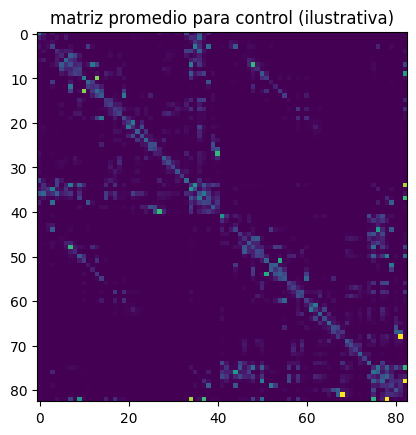

In [ ]:
plt.title('matriz promedio para control (ilustrativa)' )
plt.imshow(wij_ctrl)
plt.show()

La conectividad estructural cerebral se obtuvo mediante imágenes por espectro de difusión (DSI), calculando la densidad de fibras nerviosas entre regiones cerebrales, normalizada por la longitud promedio de las líneas de flujo y el área superficial. Esta información se organizó en una matriz $\mathbf{W}$, donde cada elemento $W_{ij}$ representa la fuerza de conexión entre las regiones $i$ y $j$.

Para modelar la dinámica cerebral en estado de reposo, se representó cada una de las 83 regiones como un nodo dinámico no lineal según el modelo **Aihara CNN**. La evolución temporal del sistema viene dada por:

$$
x_i(t+1) = f\left(\eta_i(t+1) + \zeta_i(t+1)\right)
$$

$$
\eta_i(t+1) = k_f \, \eta_i(t) + \sum_{j=1}^N w_{ij} x_j(t)
$$

$$
\zeta_i(t+1) = k_r \, \zeta_i(t) - \alpha \, x_i(t) + a_i
$$

donde:

* $x_i(t)$: salida del nodo $i$,
* $\eta_i(t)$: estado interno
* $\zeta_i(t)$: estado interno
* $f(\cdot)$: función de activación sigmoide dada por:

$$
f(x) = \frac{1}{1 + \exp(-x / \varepsilon)}
$$

* $k_f, k_r, \alpha$: parámetros dimanicos.
* $a_i$: sesgo individual de cada nodo,
* $w_{ij}$: fuerza de conexión estructural entre los nodos $i$ y $j$.




**Matriz de conectividad estructural**:

La conectividad estructural entre regiones cerebrales se representa por $W_{ij}$, basada en la densidad de fibras nerviosas. Se ajusta mediante un parámetro  $\kappa$:

   $$
   w_{ij} = \kappa W_{ij}
   $$

**Clasificación ondas cerebrales**:

   * Delta :  (1 - 3 ) Hz
   * Theta :  (4 - 7) Hz
   * Alpha :  (8 - 12) Hz
   * Beta :   (13 - 30) Hz

**Parámetros  del modelo (Aihara CNN)**

para nodo aislado, sin acoplamiento $\kappa = 0$ :

   $$
   \varepsilon = 0.02,\quad k_f = 0.15,\quad k_r = 0.5,\quad \alpha = 10,\quad a_i = 2.0
   $$

Para los demas el efecto del acoplamiento $\kappa = 40$:


#FIG 2:

---


**Oscilaciones inducidas por la conectividad estructural**:

* Las ondas **alfa (~10 Hz)** son un marcador confiable del **estado de reposo cerebral** y se correlacionan con el nivel de vigilia.
* Tanto modelos computacionales como evidencia empírica sugieren que existen múltiples **generadores alfa distribuidos** en el cerebro, que coordinan la actividad oscilatoria a gran escala.
* Estas interacciones subyacen la **dinámica compleja y no lineal** del cerebro.


**Simulación con acoplamiento estructural**:

* Las señales oscilatorias de regiones como el **Parahipocampo derecho** y la **Amígdala derecha**  muestran una clara **modulación** debida al acoplamiento.
* La FFT de estas señales  muestra una distribución espectral ampliada que incluye varias bandas de frecuencia.

**Transición alfa → beta**:

* En la **Amígdala derecha**, se observa un **desplazamiento del pico espectral** de la banda alfa hacia la banda beta.
* Esto evidencia que el **acoplamiento en red puede inducir oscilaciones beta**, vinculadas con procesos patológicos en SCHZ.



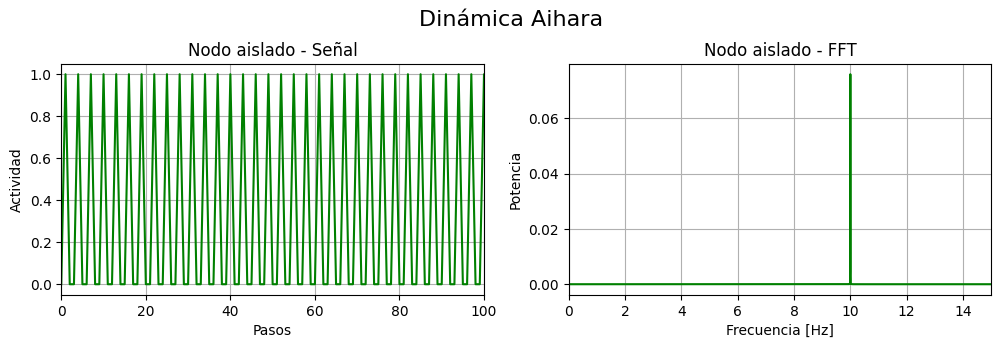

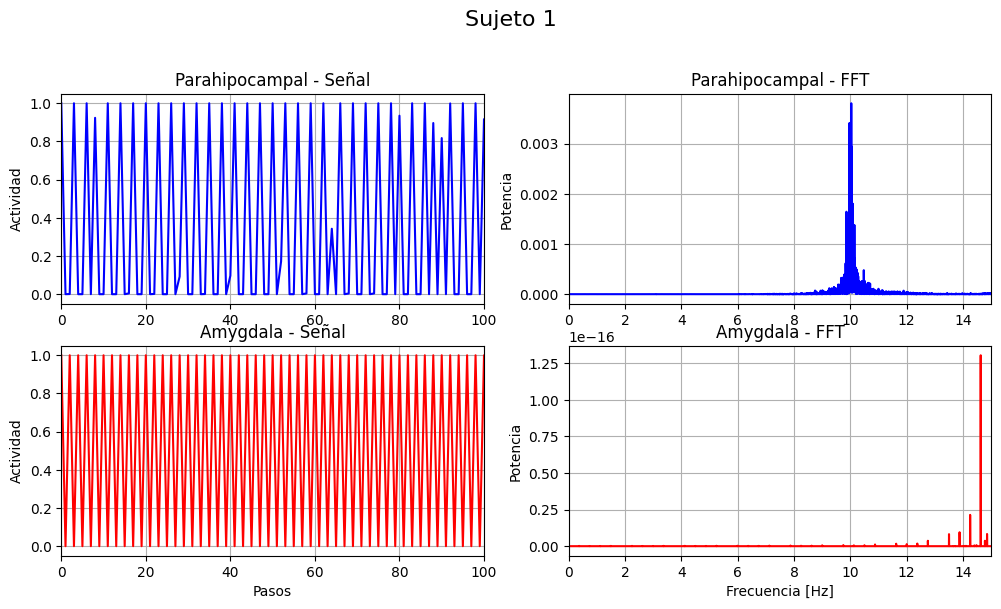

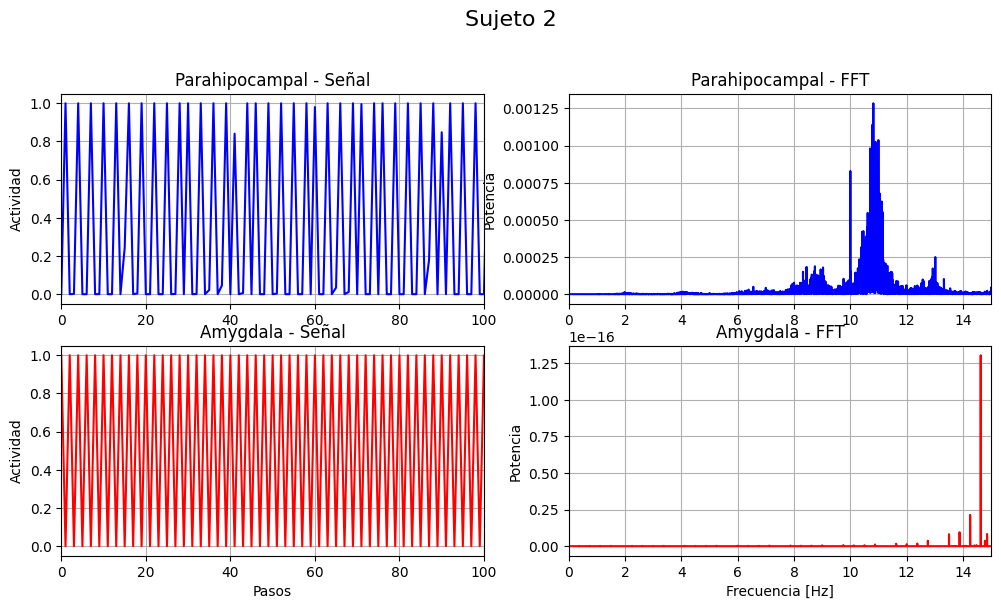

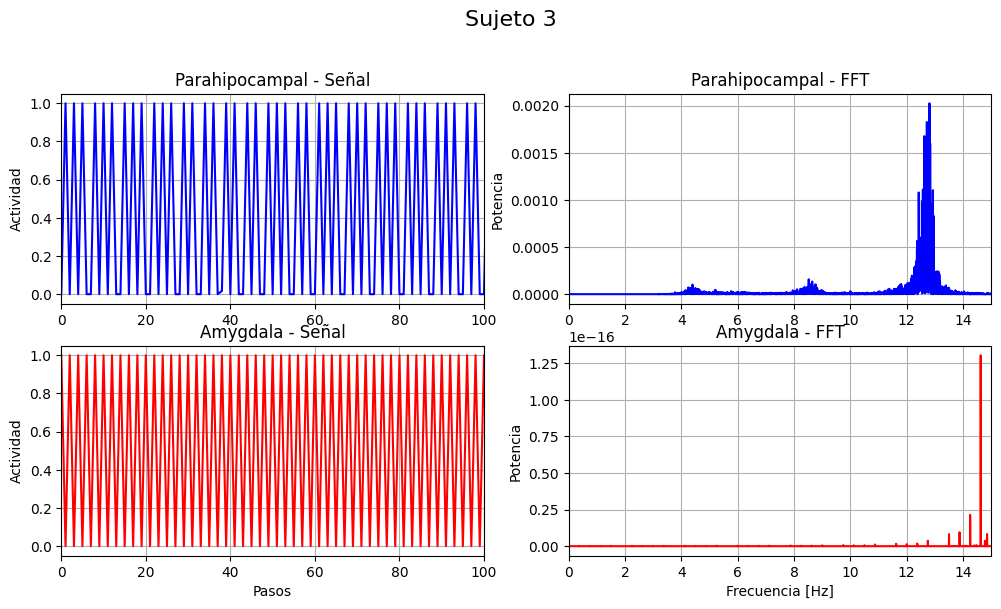

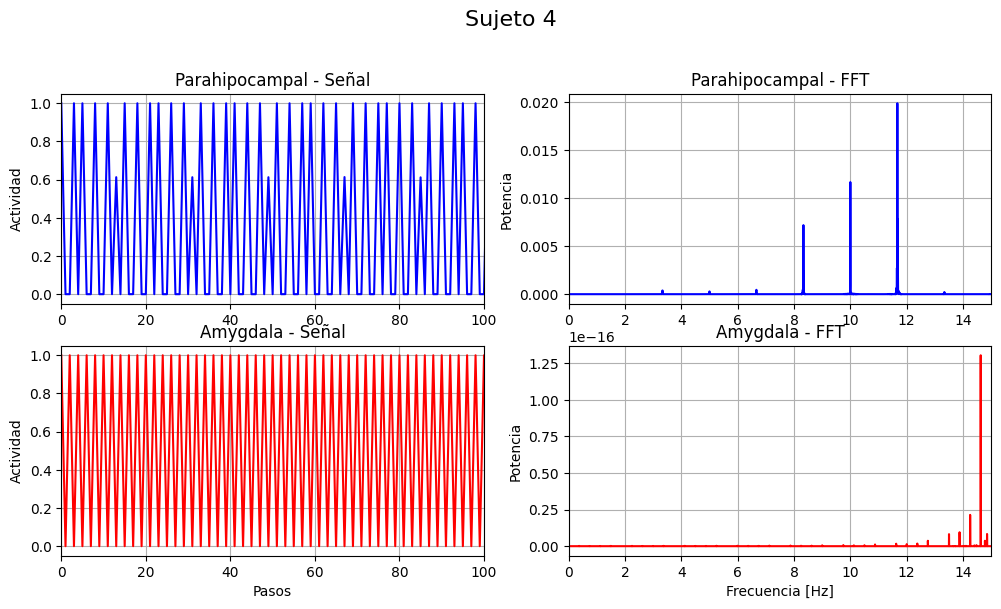

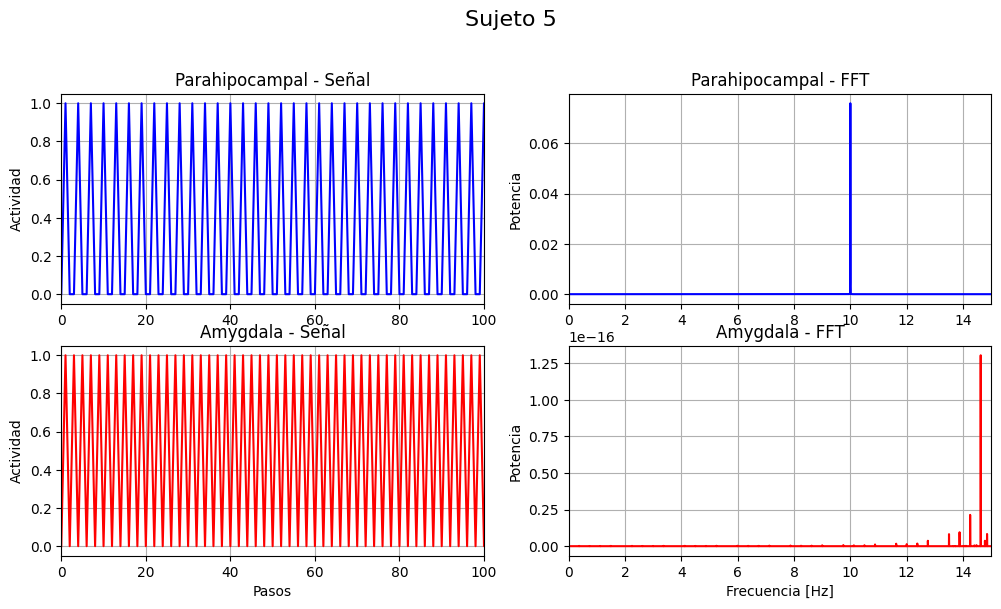

In [ ]:
# Función sigmoide
from scipy.fft import fft, fftfreq

epsilon = 0.02
@njit
def sigmoid(x):
  z = x / epsilon
  z = np.clip(z, -500, 500)
  return 1.0 / (1.0 + np.exp(-z))


#Función Aihira con transitorio descartado

@njit
def simulacion_aihara(W, T=600, kappa=40, region=0,
                    kf=0.15, kr=0.5, alpha=9.3, a=2.0,
                    transitorio=100):
  N = W.shape[0]
  W = kappa * W
  eta = np.random.rand(N)
  zeta = np.random.rand(N)
  x = sigmoid(eta + zeta)

  T_total = T + transitorio
  x_hist = np.empty(T_total, dtype=np.float32)

  for t in range(T_total):
    eta = kf * eta + W @ x
    zeta = kr * zeta - alpha * x + a
    u = eta + zeta
    x = sigmoid(u)
    x_hist[t] = x[region]

  return x_hist[transitorio:]


# FFT Y clasificacion

def espectro(x, fs=30):
  N = len(x)
  x = x - np.mean(x)
  X = fft(x)
  freqs = fftfreq(N, d=1/fs)
  psd = (np.abs(X)**2) / N**2
  mask = freqs > 0
  return freqs[mask], psd[mask]


# Parámetros generales

fs = 30
T = 10000
transitorio = 1000
idx_parahip = 25
idx_amyg = 40



# Simulación nodo aislado

x_iso = simulacion_aihara(np.zeros((83, 83)), T=T, kappa=0, region=idx_amyg, transitorio=transitorio)
f_iso, p_iso = espectro(x_iso, fs=fs)

plt.figure(figsize=(12, 3))


plt.subplot(1, 2, 1)
plt.plot(x_iso, 'green')
plt.title("Nodo aislado - Señal")
plt.xlabel("Pasos")
plt.ylabel("Actividad")
plt.xlim(0, 100)
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(f_iso, p_iso, 'green')
plt.title("Nodo aislado - FFT")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")
plt.xlim(0, 15)
plt.grid(True)

plt.suptitle("Dinámica Aihara", fontsize=16, y=1.06)
plt.subplots_adjust(hspace=0.6)
plt.show()



# Simulación por sujeto
ctrl_mats = [wij_ctrl_1[i]   for i in range(wij_ctrl_1.shape[0])]
schz_mats = [wij_schizo_1[i] for i in range(wij_schizo_1.shape[0])]
num_subj = len(schz_mats)

for n in range(5):
  W = schz_mats[n]

  x_parahip  = simulacion_aihara(W, T=T, kappa=40, region=idx_parahip, transitorio=transitorio)
  x_amyg     = simulacion_aihara(W, T=T, kappa=40, region=idx_amyg,    transitorio=transitorio)

  f_parahip, p_parahip = espectro(x_parahip, fs=fs)
  f_amyg,    p_amyg    = espectro(x_amyg,    fs=fs)

  plt.figure(figsize=(12, 6))


  plt.subplot(2, 2, 1)
  plt.plot(x_parahip, 'blue', linewidth=1.5)
  plt.title("Parahipocampal - Señal", loc='center', fontsize=12)
  plt.ylabel("Actividad")
  plt.xlim(0, 100)
  plt.grid()

  # FFT parahipocampal
  plt.subplot(2, 2, 2)
  plt.plot(f_parahip, p_parahip, 'blue', linewidth=1.5)
  plt.title("Parahipocampal - FFT", loc='center', fontsize=12)
  plt.ylabel("Potencia")
  plt.xlim(0, 15)
  plt.grid()


  # Señal amígdala
  plt.subplot(2, 2, 3)
  plt.plot(x_amyg, 'red', linewidth=1.5)
  plt.title("Amygdala - Señal", loc='center', fontsize=12)
  plt.xlabel("Pasos")
  plt.ylabel("Actividad")
  plt.xlim(0, 100)
  plt.grid()

  # FFT amígdala
  plt.subplot(2, 2, 4)
  plt.plot(f_amyg, p_amyg, 'red', linewidth=1.5)
  plt.title("Amygdala - FFT", loc='center', fontsize=12)
  plt.xlabel("Frecuencia [Hz]")
  plt.ylabel("Potencia")
  plt.xlim(0, 15)
  plt.grid()

  # Título general
  plt.suptitle(f"Sujeto {n+1}", fontsize=16, y=1.02)


  plt.show()

#FIG 3

----


*Caos y estado crítico*:

* El parámetro $\alpha$ controla el *comportamiento caótico* del sistema.
* El *mayor exponente de Lyapunov (LLE)* se usa para cuantificarlo:

     * $\text{LLE} > 0$: sistema caótico
     * $\text{LLE} < 0$: sistema estable
     * $\text{LLE} = 0$: borde del caos

*Resultados del análisis de LLE*:

* Se identifican tres puntos críticos donde el sistema cruza entre caos y estabilidad.
* No hay diferencias significativas de LLE entre grupos control y esquizofrenia en ninguno de los regímenes.

*Configuración final para simulaciones*:

Se elige $\alpha = 9.3$



Para calcular el LLE, se evoluciona una pequeña perturbación tangente:

$$
\delta \eta(t), \quad \delta \zeta(t)
$$

La evolución tangente está dada por:


$$
\delta \eta(t+1) = k_f \delta \eta(t) + W \cdot \left[ f'\left(\eta(t+1) + \zeta(t+1) \right)(\delta \eta(t) + \delta \zeta(t)) \right]
$$

$$
\delta \zeta(t+1) = k_r \delta \zeta(t) - \alpha \,\left[ f' \left(\eta(t+1) + \zeta(t+1)  \right)\left( \delta \eta + \delta \zeta \right)\right]
$$

$$
x(t) = f' \left(\eta(t+1) + \zeta(t+1)  \right)\left( \delta \eta + \delta \zeta \right)
$$

Cada 10 pasos de tiempo se normaliza el vector tangente:

$$
\|\delta(t)\| = \sqrt{\sum_i \left( \delta \eta_i^2 + \delta \zeta_i^2 \right)}
$$

Y se acumula el logaritmo de la norma para estimar el LLE:

$$
\lambda = \frac{1}{T} \sum_{k=1}^{T} \log \|\delta(t_k)\|
$$


In [ ]:
epsilon = 0.02
kf = 0.15
kr = 0.5
ai = 2
T = 50000
transitorio = 1000

@njit
def sigmoid(x):
    z = x / epsilon
    z = np.clip(z, -500, 500)             #evitar el over flow
    return 1 / (1 + np.exp(-z))

@njit
def sigmoid_prima(x):
    fx = sigmoid(x)
    return fx * (1 - fx) / epsilon        #funcion derivada


@njit
def LLE_FIG3(W, alpha):
    N = 83                                 #numero de nodos de la matriz de conectividad
    eta = np.random.randn(N)               #inicializacion de parametros pequeños y alatorios es un vector de 83 entradas de condiciones iniciales alatorias
    zeta = np.random.randn(N)
    x = sigmoid(eta + zeta)                #inicializacion de las salidas

   #evolucion infinitesimal pequeña del sistema tangente
    delta_eta = np.random.randn(N)
    delta_zeta = np.random.randn(N)
    norma = np.sqrt(np.sum(delta_eta**2 + delta_zeta **2))  #normal inicial
    delta_eta  =  delta_eta/norma                                      #vectores normalizados
    delta_zeta =  delta/ norma

    suma_log = 0                                            #acumulacion de logaritmos

    # evolucion del sistema en  fase transitoria
    for t in range(transitorio):
        eta = kf * eta + W @ x
        zeta = kr * zeta - alpha * x + ai
        x = sigmoid(eta + zeta)

    # fase de simulacion y calculo de parametros en cada sistema
    for t in range(T):
        #sistema real de Aihara ANN
        eta_next = kf * eta + W @ x
        zeta_next = kr * zeta - alpha * x + ai
        x_next = sigmoid(eta_next + zeta_next)
        #sistema tangente con las derivadas temporales

        fxp = sigmoid_prima(eta_next + zeta_next)
        delta_eta_next = kf * delta_eta + W @ (fxp * (delta_eta + delta_zeta))
        delta_x = fxp * (delta_eta + delta_zeta)
        delta_zeta_next = kr * delta_zeta - alpha * delta_x
        #se calcula la norma cada 10 iteraciones (fines de reduccion de coste computacional)
        if t % 10 == 0:
            norm = np.sqrt(np.sum(delta_eta_next**2 + delta_zeta_next**2))
            suma_log += np.log(norm)

            delta_eta = delta_eta_next / norm  #actualizacion de la norma tangente del sistema tangente
            delta_zeta = delta_zeta_next / norm
        else:
            #sino se realimenta la evolucion temporal
            delta_eta = delta_eta_next
            delta_zeta = delta_zeta_next
        #realimentacion de la evolucion del sistema real
        eta = eta_next
        zeta = zeta_next
        x = x_next

    return suma_log / T

In [ ]:
alphas = np.linspace(4, 14, 100)    #aqui tengo los valores de alpha a evaluar

#listas de acumuladores
lle_ctrl_mean = list()
lle_ctrl_std = list()

lle_schz_mean = list()
lle_schz_std = list()

cont = 1  #monitorizacion de las iteraciones

for alpha in alphas:
    #acumuladores parciales
    lles_ctrl = list()
    lles_schz = list()

    for i in range(27):

        Wc = 40*wij_ctrl_1[i]                     #iteracion sobre cada grupo
        Ws = 40*wij_schizo_1[i]

        lles_ctrl.append(LLE_FIG3(Wc,alpha))      #aplicacion de las funciones
        lles_schz.append(LLE_FIG3(Ws,alpha))
    #sacamos de inmediato la media y su desviacion  estandar  de todos los sujetos en cada grupo
    lle_ctrl_mean.append(np.mean(lles_ctrl))
    lle_ctrl_std.append(np.std(lles_ctrl))

    lle_schz_mean.append(np.mean(lles_schz))
    lle_schz_std.append(np.std(lles_schz))

    if cont % 10 == 0:
        print(f"{cont} de {len(alphas)} completado")    #monitorizacion de progreso de la simulacion

    cont += 1

10 de 100 completado
20 de 100 completado
30 de 100 completado
40 de 100 completado
50 de 100 completado
60 de 100 completado
70 de 100 completado
80 de 100 completado
90 de 100 completado
100 de 100 completado


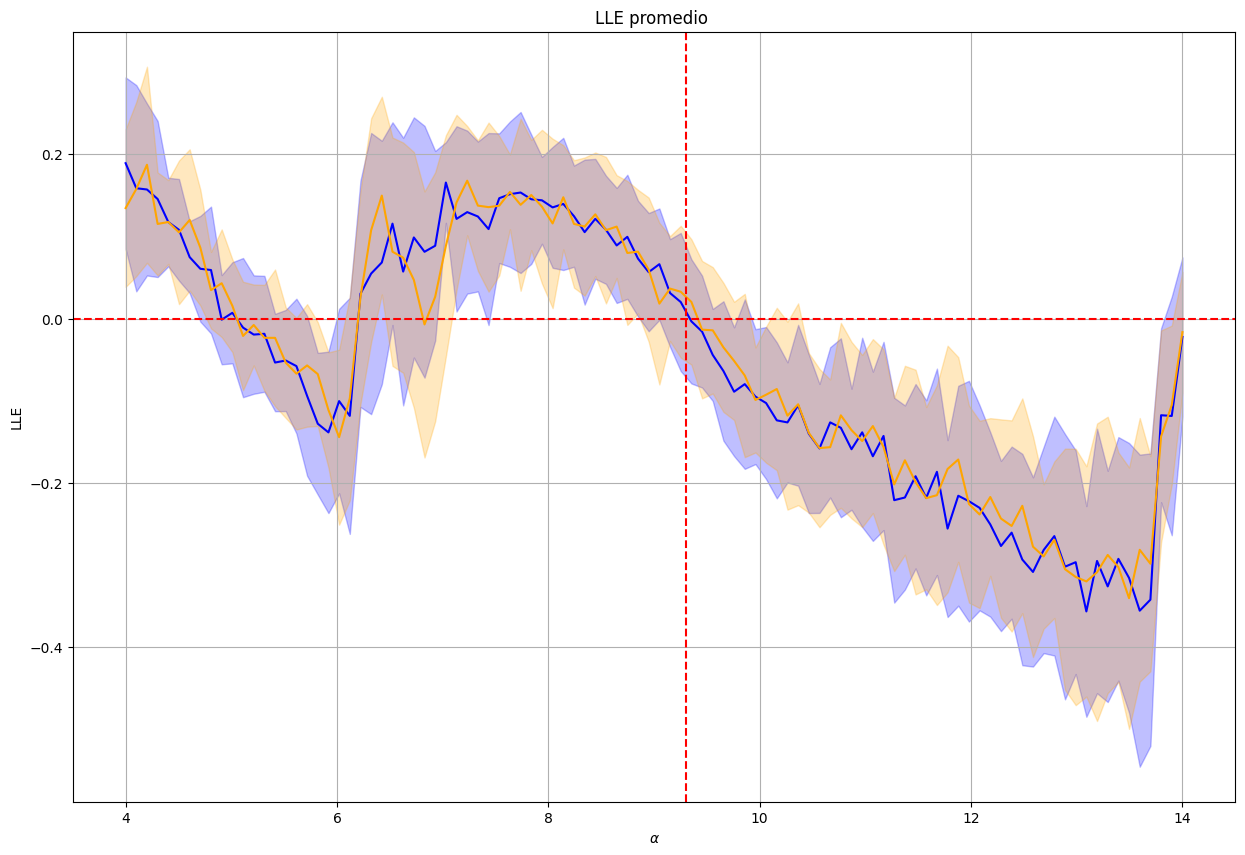

In [ ]:
plt.figure(figsize=(15,10))

# Curvas de LLE promedio
plt.plot(alphas, lle_ctrl_mean, label='Control', color='blue')
plt.plot(alphas, lle_schz_mean, label='SCHZ', color='orange')

#fill_between me permite graficar la sombre entre 2 curvas
plt.fill_between(alphas,np.array(lle_ctrl_mean) - np.array(lle_ctrl_std), np.array(lle_ctrl_mean) + np.array(lle_ctrl_std),alpha=0.25, color='blue')
plt.fill_between(alphas,np.array(lle_schz_mean) - np.array(lle_schz_std),np.array(lle_schz_mean) + np.array(lle_schz_std), alpha=0.25, color='orange')


plt.axvline(x=9.3, color='red', linestyle='--', linewidth=1.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

plt.xlabel(r"$\alpha$")
plt.ylabel("LLE")
plt.title("LLE promedio ")
plt.grid()
plt.show()

#FIG 4
----

**Distribución de ondas cerebrales por región cerebral**:

* Se analiza la dinámica cerebral en estado de reposo usando el modelo de la red caótica de Aihara sobre conectomas estructurales de sujetos **control** y **con esquizofrenia (SCHZ)**.
* Para cada sujeto, se calcula el **espectro de frecuencias** en cada región cerebral mediante **Transformada Rápida de Fourier (FFT)** aplicada a la señal $x_i(t)$.
* Se descartan los primeros 1000 puntos de cada señal y se realizan **10 repeticiones de la FFT** por región para garantizar robustez.

**Clasificación de bandas cerebrales**:

* Se identifica la **frecuencia con mayor amplitud** en el espectro para cada región.
* A partir de esta frecuencia dominante, se clasifica la onda cerebral como:
  - **Delta**: 1–3 Hz
  - **Theta**: 4–7 Hz
  - **Alfa**: 8–12 Hz
  - **Beta**: 13–30 Hz



**Resultado visual**:

* La **parte superior** de la figura muestra la distribución por región de los tipos principales de onda en el grupo SCHZ.
* La **parte inferior** muestra lo mismo para el grupo control.
* Se observa que la mayoría de regiones exhiben actividad **alfa**, aunque también se identifican regiones con actividad **beta**, especialmente en redes como DMN, SMN y BGN.





In [ ]:
import time
import sys


# Clasificación de bandas
def banda_dominante(x, fs=30):
  f, p = espectro(x, fs)
  f_peak = f[np.argmax(p)]
  if 1 <= f_peak < 4: return 0  # Delta
  elif 4 <= f_peak < 8: return 1  # Theta
  elif 8 <= f_peak < 13: return 2  # Alpha
  else: return 3  # Beta


# Matriz de banda por sujeto y región cerebral
def matriz_bandas(grupo_matrices, T=600, transitorio=100, fs=30, repeticiones=20):
  out = np.empty((n_sujetos, n_regiones), dtype=np.uint8)
  t0 = time.time()

  for subj in range(n_sujetos):
    W = grupo_matrices[subj]
    for reg in range(n_regiones):
      counts = np.zeros(4, dtype=int)
      for _ in range(repeticiones):
        x = simulacion_aihara(W, T=T, region=reg, transitorio=transitorio)
        banda = banda_dominante(x, fs)
        counts[banda] += 1
      out[subj, reg] = counts.argmax()
    print(f"Sujeto {subj+1}/{n_sujetos} procesado", file=sys.stderr)

  print(f"Tiempo total: {time.time() - t0:.1f}s", file=sys.stderr)
  return out


In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

# Parámetros generales

fs = 30
T = 5000
transitorio = 1000
repeticiones = 10
n_sujetos = 27
n_regiones = 83
# Simulación de ambos grupos

bandas_ctrl = matriz_bandas(wij_ctrl_1, T=T, transitorio=transitorio, fs=30)
bandas_schz = matriz_bandas(wij_schizo_1, T=T, transitorio=transitorio, fs=30)


Sujeto 1/27 procesado
Sujeto 2/27 procesado
Sujeto 3/27 procesado
Sujeto 4/27 procesado
Sujeto 5/27 procesado
Sujeto 6/27 procesado
Sujeto 7/27 procesado
Sujeto 8/27 procesado
Sujeto 9/27 procesado
Sujeto 10/27 procesado
Sujeto 11/27 procesado
Sujeto 12/27 procesado
Sujeto 13/27 procesado
Sujeto 14/27 procesado
Sujeto 15/27 procesado
Sujeto 16/27 procesado
Sujeto 17/27 procesado
Sujeto 18/27 procesado
Sujeto 19/27 procesado
Sujeto 20/27 procesado
Sujeto 21/27 procesado
Sujeto 22/27 procesado
Sujeto 23/27 procesado
Sujeto 24/27 procesado
Sujeto 25/27 procesado
Sujeto 26/27 procesado
Sujeto 27/27 procesado
Tiempo total: 1137.0s
Sujeto 1/27 procesado
Sujeto 2/27 procesado
Sujeto 3/27 procesado
Sujeto 4/27 procesado
Sujeto 5/27 procesado
Sujeto 6/27 procesado
Sujeto 7/27 procesado
Sujeto 8/27 procesado
Sujeto 9/27 procesado
Sujeto 10/27 procesado
Sujeto 11/27 procesado
Sujeto 12/27 procesado
Sujeto 13/27 procesado
Sujeto 14/27 procesado
Sujeto 15/27 procesado
Sujeto 16/27 procesado
Sujeto 

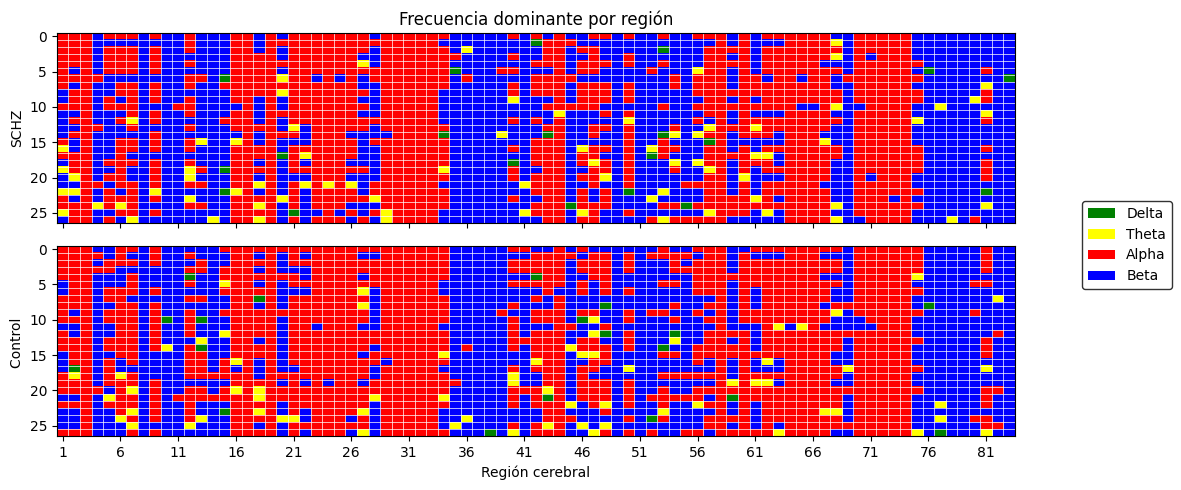

In [ ]:

# Colormap y normalización
cmap = ListedColormap(['green', 'yellow', 'red', 'blue'])
bounds = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm = BoundaryNorm(bounds, cmap.N)


fig, axs = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# SCHZ
im1 = axs[0].imshow(bandas_schz, aspect='auto', cmap=cmap, norm=norm)
axs[0].set_ylabel("SCHZ")
axs[0].set_title("Frecuencia dominante por región")
axs[0].set_yticks([0, 5, 10, 15, 20, 25])
axs[0].set_xticks(np.arange(0, 83, 5))
axs[0].set_xticklabels(np.arange(1, 84, 5))

# Grilla menor para SCHZ
axs[0].set_xticks(np.arange(-0.5, 83, 1), minor=True)
axs[0].set_yticks(np.arange(-0.5, 27, 1), minor=True)
axs[0].grid(which='minor', color='white', linewidth=0.5)
axs[0].tick_params(which='minor', bottom=False, left=False)

# CTRL
im2 = axs[1].imshow(bandas_ctrl, aspect='auto', cmap=cmap, norm=norm)
axs[1].set_ylabel("Control ")
axs[1].set_xlabel("Región cerebral")
axs[1].set_yticks([0, 5, 10, 15, 20, 25])
axs[1].set_xticks(np.arange(0, 83, 5))
axs[1].set_xticklabels(np.arange(1, 84, 5))

# Grilla menor para CTRL
axs[1].set_xticks(np.arange(-0.5, 83, 1), minor=True)
axs[1].set_yticks(np.arange(-0.5, 27, 1), minor=True)
axs[1].grid(which='minor', color='white', linewidth=0.5)
axs[1].tick_params(which='minor', bottom=False, left=False)

# Legend
legend_elems = [
    Patch(facecolor='green', label='Delta'),
    Patch(facecolor='yellow', label='Theta'),
    Patch(facecolor='red', label='Alpha'),
    Patch(facecolor='blue', label='Beta')
]
fig.legend(
    handles=legend_elems,
    loc='center left',
    bbox_to_anchor=(0.9, 0.5),
    frameon=True,
    edgecolor='black'
)

plt.tight_layout()
plt.subplots_adjust(right=0.85)  # espacio a la derecha para leyenda
plt.show()


# FIG 5
----

**Comparación de bandas cerebrales en regiones específicas**:

* Se realiza un análisis comparativo de la distribución de **ondas cerebrales dominantes** entre los grupos **Control** y **SCHZ**, en cuatro regiones cerebrales del hemisferio derecho:

  - Caudal anterior del cíngulo (R)
  - Istmo del cíngulo (R)
  - Polo temporal (R)
  - Amígdala (R)

**Metodología**:

* A partir de las frecuencias dominantes obtenidas en la simulación (ver Fig. 4), se contabiliza la cantidad de veces que cada tipo de onda cerebral (Delta, Theta, Alfa, Beta) aparece en cada una de las regiones seleccionadas.
* Este conteo se realiza de forma separada para el grupo **Control** y el grupo **SCHZ**.

**Resultado visual**:

* Se presentan **diagramas de barras** para cada región, donde se comparan los conteos de cada tipo de onda entre ambos grupos.
* Se observa que en todas las regiones analizadas predomina la **actividad Beta**, especialmente en el grupo SCHZ.
* En regiones como la amígdala y el polo temporal, el grupo SCHZ muestra una mayor incidencia de **ondas Beta** en comparación con el grupo control.
* Las bandas **Delta** y **Theta** están prácticamente ausentes en estas regiones, indicando una dominancia de frecuencias altas en la dinámica simulada.


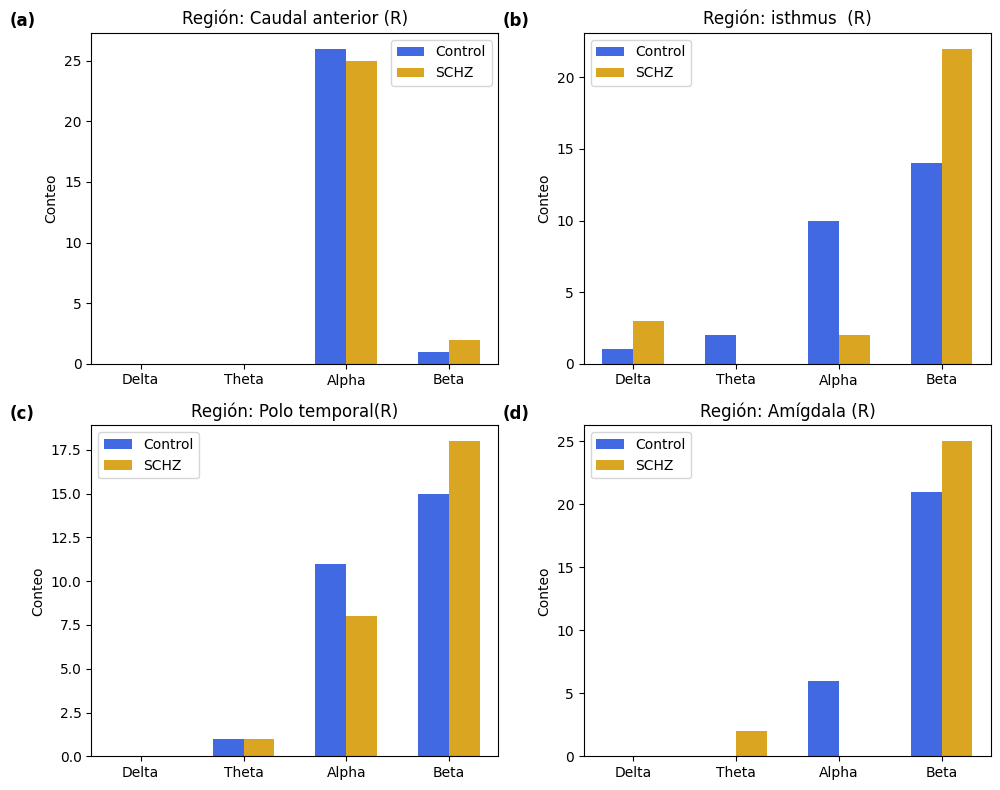

In [ ]:

# Índices de las regiones
regiones = [22, 14, 27, 40]
nombres = ['Caudal anterior (R)', 'isthmus  (R)',
           'Polo temporal(R)', 'Amígdala (R)']


fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs = axs.flatten()

for i, idx in enumerate(regiones):
  # Conteo por banda
  schz_counts = np.bincount(bandas_schz[:, idx], minlength=4)
  ctrl_counts = np.bincount(bandas_ctrl[:, idx], minlength=4)

  x = np.arange(4)
  axs[i].bar(x - 0.15, ctrl_counts, width=0.3, label='Control', color='royalblue')
  axs[i].bar(x + 0.15, schz_counts, width=0.3, label='SCHZ', color='goldenrod')

  axs[i].set_xticks(x)
  axs[i].set_xticklabels(['Delta', 'Theta', 'Alpha', 'Beta'])
  axs[i].set_ylabel('Conteo')
  axs[i].set_title(f'Región: {nombres[i]}')
  axs[i].legend()

# Etiquetas (a), (b), ...
for i, ax in enumerate(axs):
  ax.text(-0.2, 1.02, f'({chr(97+i)})', transform=ax.transAxes,
          fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

#FIGURA 6

---

### GRAFOS DIRIGIDOS Y NO DIRIGIDOS

* En un grafo no dirigido, los nodos están conectados por enlaces simétricos, sin dirección: si un nodo A está conectado a B, también lo está B a A. Es decir, es simétrica.

* En un grafo dirigido, los nodos se conectan mediante enlaces con dirección, por lo que un nodo puede tener conexiones entrantes y salientes, representando relaciones asimétricas. La matriz A no necesariamente es simétrica

### Grado:

Se trata del número de conexiones que mantiene un nodo.

### Fuerza de conexiones:

Es el peso combinado de  cada una de las  conexiones que presenta un grafo.

###densidad de conexiones:

La densidad un grado indica que tan conectado esta un conjunto de nodos  con relación con el número máximo posible de conexiones.



Para gráficos no dirigidos:

$$
d = \frac{2m}{n(n - 1)}
$$

Para gráficos dirigidos:

$$
d = \frac{m}{n(n - 1)}
$$

###clustering coefficient:

Es una medida de tendencia a formar grupos o comunidades locales.

$$
C = \frac{1}{n} \sum_{v \in G} c_v
$$

### Longitud del camino mas corto:  

Se trata del numero de aristas minimo o el peso total de las mismas que deben recorrerse para ir de un nodo a otro.


$$
d(u, v) = \min \sum_{(i, j) \in P} w(i, j)
$$

###Intermediacion:

Centralidad de intermediación de un nodo $v$ es la suma de la fracción de caminos más cortos de todos los pares que pasan por $v$:

$$
c_B(v) = \sum_{s,t \in V} \frac{\sigma(s,t \mid v)}{\sigma(s,t)}
$$


###aficiencia global:

La eficiencia de un par de nodos en un grafo es el inverso multiplicativo de la distancia de ruta más corta entre los nodos. La eficiencia global promedio de un grafo es la eficiencia promedio de todos los pares de nodos


### t - test
la prueba o tambien conocida como t-student, se usa para realizar pruebas de hiotesis  y evaluar las medidas de un grupo o varios Una prueba t puede usarse para determinar si un único grupo difiere de un valor conocido (una prueba t de una muestra), si dos grupos difieren entre sí (prueba t de muestras independientes), o si hay una diferencia significativa en medidas pareadas (una prueba t de muestras dependientes o pareada).


In [ ]:
#comprobacion de grafos dirigidos

def es_simetrica(matriz, atol=1e-8):
    return np.allclose(matriz, matriz.T, atol=atol)  #compara si los arrays son similares en caso de que la trnapuesta y la matris sean iguales la matriz es simetrica
                                                     #el atol es un umbral de comparacion  ya que hay elemento que pueden ser similares pero con decimales extras
def binarizar(matriz):
    matriz = matriz.copy()                           #esta funcion calcula la matriz binaria  de una matriz de entrada
    binaria = (matriz > 0).astype(int)               #la mascara transforma de booleanos a enteros
    np.fill_diagonal(binaria, 0)                     #elimino la auto conexiones que vendrian siendo la diegonales
    return binaria

def connection_strength(matriz):                     #opara la fuerza segun la teoria se puede usar network nx
    matriz =matriz.copy()                            #yo uso copias para evitar modificar la informacion de las matrices originales puesto que las voy a necesitar
    G = nx.from_numpy_array(matriz)
    fuerza_nodos = dict(G.degree(weight='weight'))  #segun la documentacion devuelve un dict con los nodos y su peso, en dicho caso el peso es la fuerza de conexion
    fuerza_total = sum(fuerza_nodos.values())       #sumo sobre los valores de las claves del diccionario
    return fuerza_total

def density_connection(matriz_bin):                 #recursivamente uso la funcion de binarizacion para odtener la matriz binaria que se menciona en el articulo
    matriz_bin = matriz_bin.copy()                  #uso una copia pues planeo iterar varias veces y corro el riesgo de modificar datos
    G = nx.from_numpy_array(matriz_bin)             #esta funcion crea un odjeto network graph a partir de una matriz que se puede usar con la libreria
    return nx.density(G)                            #calculamos la densidad

def clustering_global(matriz_bin):
    matriz_bin = matriz_bin.copy()
    G = nx.from_numpy_array(matriz_bin)
    return nx.average_clustering(G)                #devuelve el promedio del clistering de un grafo

def shortest_path_length(matriz_bin):
    matriz_bin = matriz_bin.copy()
    G = nx.from_numpy_array(matriz_bin)
    return nx.average_shortest_path_length(G)     #devuelve el promedio del ccamino mas corto

def betweenness(metriz_bin):
    matriz_bin = metriz_bin.copy()
    G =  nx.from_numpy_array(metriz_bin)
    b= nx.betweenness_centrality(G)               #devuelve la centralidad de intermediacion:  devuelve un diccionario
    return np.mean(list(b.values()))

def eficiencia_global(matriz_bin):
    matriz_bin = matriz_bin.copy()
    G = nx.from_numpy_array(matriz_bin)

    return nx.global_efficiency(G)             #calculo de la eficiencia global en base a la estructura anterior




In [ ]:
#comprobamos si el grafo es dirijido

for i in range(27):
    grafo_ctrl = wij_ctrl_1[i]            #iteramos sobre los sujetos
    grafo_schizo = wij_schizo[i]

    sim_ctrl = es_simetrica(grafo_ctrl)   #aplicacion de la funcion
    sim_schz = es_simetrica(grafo_schizo)

    if sim_ctrl:                           #determinamos si el grafo es dirigido o no
        valor = 'NO'
    else:
        valor = 'si'


    print(f'Sujeto {i} - Control: ¿Es un grafo dirigido? {valor}')
    print(f'Sujeto {i} - SCHZ:    ¿Es un grafo dirigido? {valor}')


Sujeto 0 - Control: ¿Es un grafo dirigido? NO
Sujeto 0 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 1 - Control: ¿Es un grafo dirigido? NO
Sujeto 1 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 2 - Control: ¿Es un grafo dirigido? NO
Sujeto 2 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 3 - Control: ¿Es un grafo dirigido? NO
Sujeto 3 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 4 - Control: ¿Es un grafo dirigido? NO
Sujeto 4 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 5 - Control: ¿Es un grafo dirigido? NO
Sujeto 5 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 6 - Control: ¿Es un grafo dirigido? NO
Sujeto 6 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 7 - Control: ¿Es un grafo dirigido? NO
Sujeto 7 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 8 - Control: ¿Es un grafo dirigido? NO
Sujeto 8 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 9 - Control: ¿Es un grafo dirigido? NO
Sujeto 9 - SCHZ:    ¿Es un grafo dirigido? NO
Sujeto 10 - Control: ¿Es un grafo dirigido? NO
Sujeto 10 - SCHZ:    ¿Es un grafo

In [ ]:
#calculo usando las funciones anteriores


################################### figura 6A #########################################################
cs_ctrl = list()
cs_schizo = list()


#sobre el conjunto de sujetos se aplican las funciones definifas previamente
for i in range(27):

    D = connection_strength(wij_ctrl_1[i])
    cs_ctrl.append(D)

for i in range(27):

    D = connection_strength(wij_schizo_1[i])
    cs_schizo.append(D)

#calculos estadisticos
cs_mean_ctrl = np.mean(cs_ctrl)
cs_std_ctrl = np.std(cs_ctrl)

cs_mean_schizo = np.mean(cs_schizo)
cs_std_schizo = np.std(cs_schizo)

#prueba estadistica
t_stat_a, p_val_a = ttest_ind(cs_ctrl,cs_schizo)  #aplicamos la prueba t-test mencionada en el articulo


########################################  figura 6B ########################################################
dens_ctrl = list()
dens_schizo = list()

for i in range(27):
    bin_ctrl = binarizar(wij_ctrl_1[i])
    D = density_connection(bin_ctrl)
    dens_ctrl.append(D)

for i in range(27):
    bin_schizo = binarizar(wij_schizo_1[i])
    D = density_connection(bin_schizo)
    dens_schizo.append(D)

#calculos estadisticos
dens_mean_ctrl = np.mean(dens_ctrl)
dens_std_ctrl = np.std(dens_ctrl)

dens_mean_schizo = np.mean(dens_schizo)
dens_std_schizo = np.std(dens_schizo)

#prueba estadistica
t_stat_b, p_val_b = ttest_ind(dens_ctrl,dens_schizo)


############################################# figura 6C ######################################################

cluster_coef_ctrl = list()
cluster_coef_schizo = list()

for i in range(27):
    bin_ctrl = binarizar(wij_ctrl_1[i])
    bin_schizo = binarizar(wij_schizo_1[i])


    cluster_ctrl = clustering_global(bin_ctrl)
    cluster_schizo = clustering_global(bin_schizo)

    cluster_coef_ctrl.append(cluster_ctrl)
    cluster_coef_schizo.append(cluster_schizo)

# Estadísticas
cluster_mean_ctrl = np.mean(cluster_coef_ctrl)
cluster_std_ctrl = np.std(cluster_coef_ctrl)

cluster_mean_schizo = np.mean(cluster_coef_schizo)
cluster_std_schizo = np.std(cluster_coef_schizo)

# T-test

t_stat_c, p_val_c = ttest_ind(cluster_coef_ctrl, cluster_coef_schizo, equal_var=False)

############################################ figura 6D #################################



spl_ctrl = list()
spl_schizo = list()

for i in range(wij_ctrl_1.shape[0]):
    bin_ctrl = binarizar(wij_ctrl_1[i])
    L = shortest_path_length(bin_ctrl)
    spl_ctrl.append(L)

for i in range(wij_schizo_1.shape[0]):
    bin_schizo = binarizar(wij_schizo_1[i])
    L = shortest_path_length(bin_schizo)
    spl_schizo.append(L)


sl_mean_ctrl_short = np.mean(spl_ctrl)
sl_std_ctrl_short = np.std(spl_ctrl)
sl_mean_schizo_short = np.mean(spl_schizo)
sl_std_schizo_shortt = np.std(spl_schizo)


t_stat_d, p_val_d = ttest_ind(spl_ctrl, spl_schizo)

######################################### Figura 6E ##################################

bet_ctrl = list()
bet_schizo = list()

for i in range(27):
    bin_ctrl = binarizar(wij_ctrl_1[i])
    bin_schizo = binarizar(wij_schizo_1[i])


    b_ctrl = betweenness(bin_ctrl)
    b_schizo = betweenness(bin_schizo)

    bet_ctrl.append(b_ctrl)
    bet_schizo.append(b_schizo)

# Estadísticas
bet_mean_b_ctrl = np.mean(bet_ctrl)
bet_std_b_ctrl = np.std(bet_ctrl)

bet_mean_b_schizo = np.mean(bet_schizo)
bet_std_b_schizo = np.std(bet_schizo)

# T-test

t_stat_e, p_val_e = ttest_ind(bet_ctrl, bet_schizo)

############################################# Figura 6F #######################################

eff_ctrl = list()
eff_schizo = list()

for i in range(wij_ctrl_1.shape[0]):
    bin_ctrl = binarizar(wij_ctrl_1[i])
    E = eficiencia_global(bin_ctrl)
    eff_ctrl.append(E)

for i in range(wij_schizo_1.shape[0]):
    bin_schizo = binarizar(wij_schizo_1[i])
    E = eficiencia_global(bin_schizo)
    eff_schizo.append(E)



# Estadísticas
eff_mean_ctrl = np.mean(eff_ctrl)
eff_std_ctrl = np.std(eff_ctrl)
eff_mean_schizo = np.mean(eff_schizo)
eff_std_schizo = np.std(eff_schizo)

# T-test
t_stat_f, p_val_f = ttest_ind(eff_ctrl, eff_schizo)

####################### resultados de ruebas estadisticas



print("resultados de las pruebas t - test:")
print(f"Figura 6A (T-TEST): t  = {t_stat_a} , p = {p_val_a}")
print(f"Figura 6B (T-TEST): t  = {t_stat_b} , p = {p_val_b}")
print(f"Figura 6C (T-TEST): t  = {t_stat_c} , p = {p_val_c}")
print(f"Figura 6D (T-TEST): t  = {t_stat_d} , p = {p_val_d}")
print(f"Figura 6E (T-TEST): t  = {t_stat_e} , p = {p_val_e}")
print(f"Figura 6F (T-TEST): t  = {t_stat_f} , p = {p_val_f}")

resultados de las pruebas t - test:
Figura 6A (T-TEST): t  = -3.027843411353187 , p = 0.0038273827106159054
Figura 6B (T-TEST): t  = -1.9166627980318776 , p = 0.06078383705761704
Figura 6C (T-TEST): t  = -2.629369154938368 , p = 0.011257094260283446
Figura 6D (T-TEST): t  = 1.4716497178649979 , p = 0.14714198271224413
Figura 6E (T-TEST): t  = 1.4716497178650128 , p = 0.14714198271224013
Figura 6F (T-TEST): t  = -1.7216097272523632 , p = 0.09108492887926078


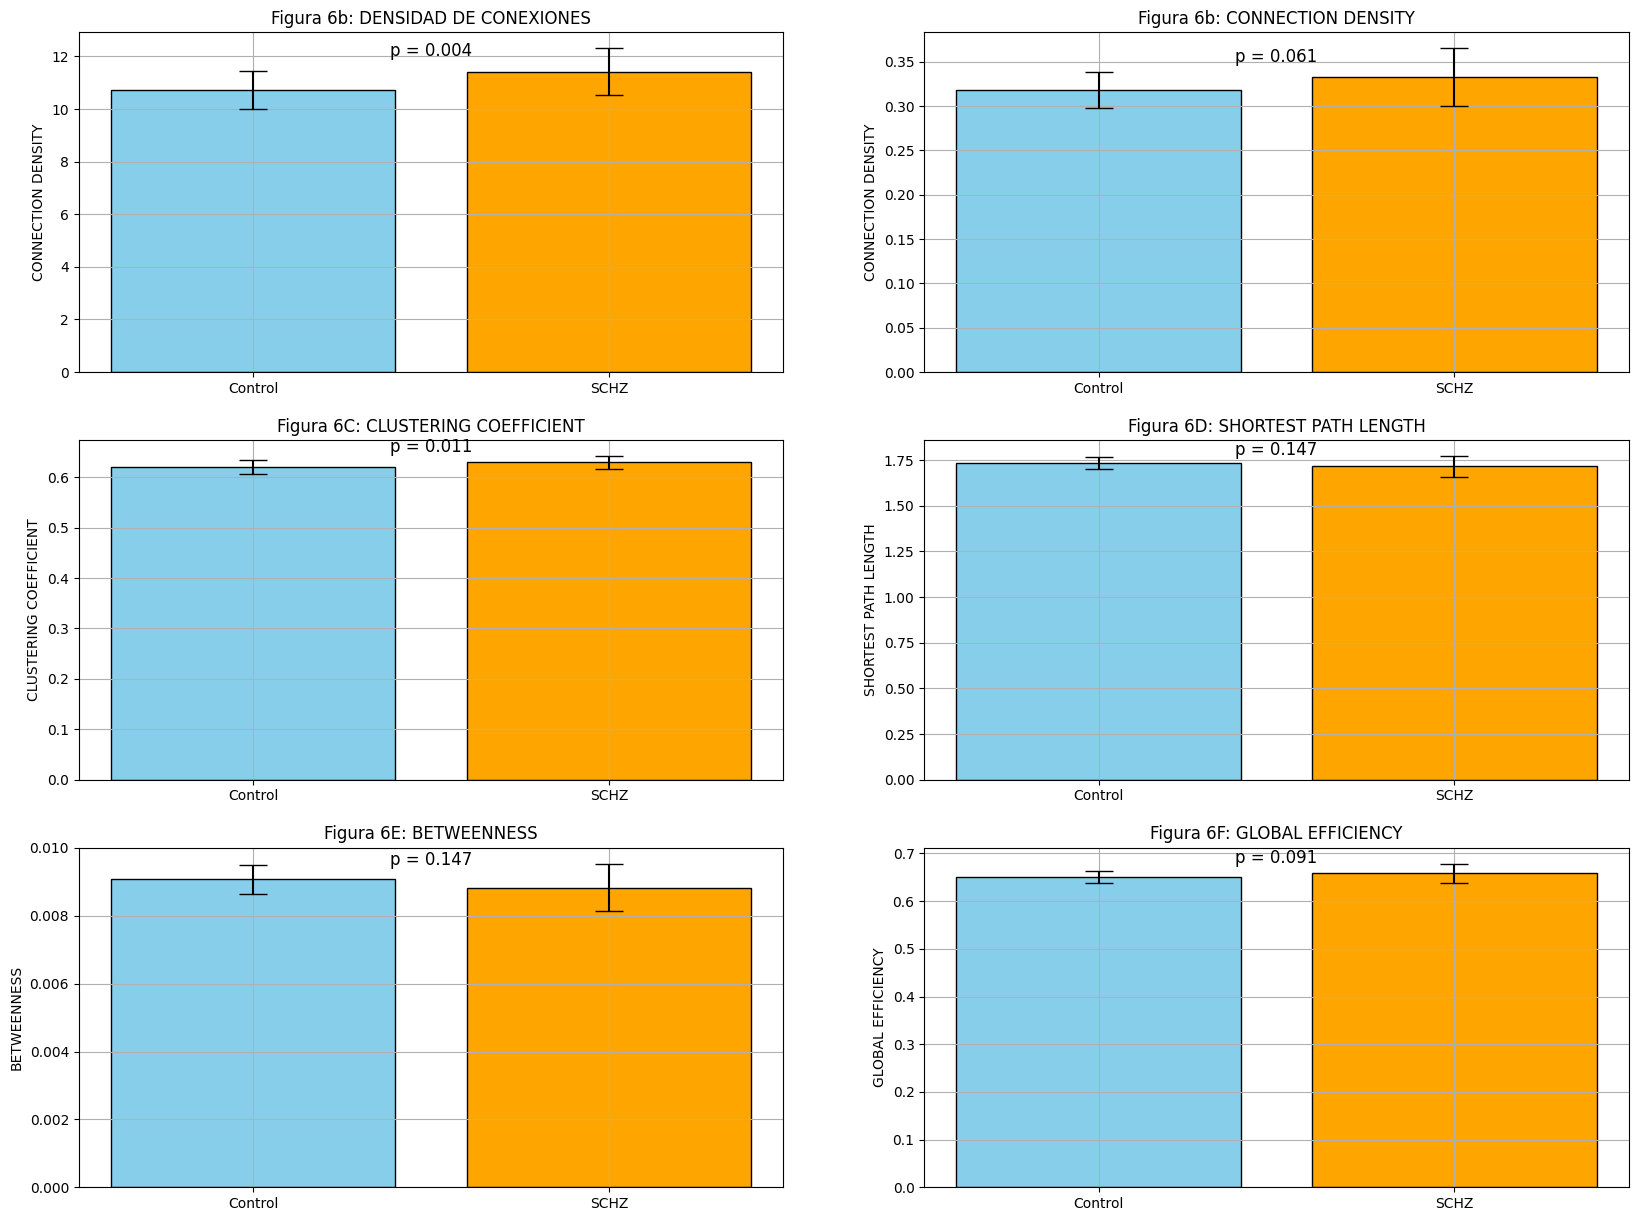

In [ ]:
#GRAFICAS

#configuracion grafica

plt.figure(figsize=(20, 15))


plt.subplot(3, 2, 1)
plt.bar(['Control', 'SCHZ'], [cs_mean_ctrl, cs_mean_schizo],yerr=[cs_std_ctrl, cs_std_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 12, f'p = {round(p_val_a, 3)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION DENSITY')
plt.title('Figura 6b: DENSIDAD DE CONEXIONES')
plt.grid()


plt.subplot(3, 2, 2)
plt.bar(['Control', 'SCHZ'], [dens_mean_ctrl, dens_mean_schizo],yerr=[dens_std_ctrl, dens_std_schizo], capsize=10, edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 0.35, f'p = {round(p_val_b, 3)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION DENSITY')
plt.title('Figura 6b: CONNECTION DENSITY')
plt.grid()

plt.subplot(3, 2, 3)
plt.bar(['Control', 'SCHZ'], [cluster_mean_ctrl, cluster_mean_schizo],yerr=[cluster_std_ctrl, cluster_std_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 0.65, f'p = {round(p_val_c, 3)}', ha='center', fontsize=12)
plt.ylabel("CLUSTERING COEFFICIENT")
plt.title('Figura 6C: CLUSTERING COEFFICIENT')
plt.grid()

plt.subplot(3, 2, 4)
plt.bar(['Control', 'SCHZ'], [sl_mean_ctrl_short, sl_mean_schizo_short],yerr=[sl_std_ctrl_short, sl_std_schizo_shortt], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 1.78, f'p = {round(p_val_d, 3)}', ha='center', fontsize=12)
plt.ylabel('SHORTEST PATH LENGTH')
plt.title('Figura 6D: SHORTEST PATH LENGTH')
plt.grid()

plt.subplot(3, 2, 5)
plt.bar(['Control', 'SCHZ'], [bet_mean_b_ctrl, bet_mean_b_schizo],yerr=[bet_std_b_ctrl, bet_std_b_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 0.0095, f'p = {round(p_val_e, 3)}', ha='center', fontsize=12)
plt.ylabel('BETWEENNESS')
plt.title('Figura 6E: BETWEENNESS')
plt.grid()

plt.subplot(3, 2, 6)
plt.bar(['Control', 'SCHZ'], [eff_mean_ctrl, eff_mean_schizo], yerr=[eff_std_ctrl, eff_std_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5, 0.68, f'p = {round(p_val_f, 3)}', ha='center', fontsize=12)
plt.ylabel('GLOBAL EFFICIENCY')
plt.title('Figura 6F: GLOBAL EFFICIENCY')
plt.grid()

plt.show()


#FIG 7

---


In [ ]:
#reusando funciones

#las funciones son similares a las anteriores  solo que ahora las extendemos para que reciban nodos especificos para calcular las metricas
#aproivechando que las funciones de  networkx tienen esas opciones dentro de su documentacion
def fuerza_de_nodo_nx(matriz, nodo_idx):
    matriz = matriz.copy()
    G = nx.from_numpy_array(matriz)
    return G.degree(nodo_idx, weight='weight')


def clustering_nodo(matriz, nodo_idx):
    matriz = matriz.copy()
    G = nx.from_numpy_array(matriz)
    return nx.clustering(G, nodo_idx)


def avg_shortest_path_nodo(matriz_bin, nodo_idx):
    G = nx.from_numpy_array(matriz_bin)
    dist = dict(nx.shortest_path_length(G, source=nodo_idx))
    return np.mean(list(dist.values()))

def degree_nodo(matriz_bin, nodo_idx):
    G = nx.from_numpy_array(matriz_bin)
    return G.degree[nodo_idx]


In [ ]:
#PRIMERAS 4 FIGURAS

#para el caudal interior
cudal_int_cs_ctrl = list()
cudal_int_cs_schizo = list()

#para ithsmus cingular  cortex

cortex_ctrl = list()
cortex_schizo = list()

#para temporal pole
temp_ctrl = list()
temp_schizo = list()

#para amigdala

amygdala_ctrl = list()
amygdala_schizo = list()



#para la amigdala

for i in range(27):

    #iteracion sobre el nodo 13 (en la tabla) para nosotros el 12 por python  (cuadal interior)
    cs_cudal_ctrl =fuerza_de_nodo_nx(wij_ctrl_1[i], 12 )
    cs_cudal_schizo = fuerza_de_nodo_nx(wij_schizo_1[i],12)
    cudal_int_cs_ctrl.append(cs_cudal_ctrl)
    cudal_int_cs_schizo.append(cs_cudal_schizo)

    #iteracion sobre el nodo 15 (en la tabla)  para nosotros el 14 por python(ithsmus cingular cortex)
    c_ctrl =fuerza_de_nodo_nx(wij_ctrl_1[i], 14 )
    c_schizo = fuerza_de_nodo_nx(wij_schizo_1[i],14)
    cortex_ctrl.append(c_ctrl)
    cortex_schizo.append(c_schizo)

   #iteracion sobre el nodo 28 (en la tabla)  para nosotros el 27 por python(polo temporal )

    t_ctrl =fuerza_de_nodo_nx(wij_ctrl_1[i], 27 )
    t_schizo = fuerza_de_nodo_nx(wij_schizo_1[i], 27)
    temp_ctrl.append(t_ctrl)
    temp_schizo.append(t_schizo)

    #iteracion sobre el nodo 41 (en la tabla)  para nosotros el 40 por python(amygdala)

    a_ctrl =fuerza_de_nodo_nx(wij_ctrl_1[i], 40 )
    a_schizo = fuerza_de_nodo_nx(wij_schizo_1[i],40)
    amygdala_ctrl.append(a_ctrl)
    amygdala_schizo.append(a_schizo)


#CLUSTERING COEFICIENT  CAUDAL INTERIOR
cluster_cudal_ctrl = list()
cluster_cudal_schizo = list()

for i in range(27):
    bin_cau_ctrl = binarizar(wij_ctrl_1[i])
    bin_cau_schizo  = binarizar(wij_schizo_1[i])

    cluster_cudal_ctrl.append(clustering_nodo(bin_cau_ctrl     , 12))
    cluster_cudal_schizo.append(clustering_nodo(bin_cau_schizo , 12))
#SHORTEST PATH LENGHT

shortes_cau_ctrl =list()
shortes_cua_schizo = list()

for i in range(27):
    bin_short_ctrl = binarizar(wij_ctrl_1[i])
    bin_short_schizo  = binarizar(wij_schizo_1[i])

    shortes_cau_ctrl.append(avg_shortest_path_nodo(bin_short_ctrl     , 12))
    shortes_cua_schizo.append(avg_shortest_path_nodo(bin_short_schizo , 12))

#degree para figuras  e y h
cau_degree_ctrl = list()
cau_degree_schizo = list()

ishtmus_degree_ctrl = list()
ishtmus_degree_schizo = list()

for i in range(27):

    #degree para caudal
    bin_cau_ctrl = binarizar(wij_ctrl_1[i])
    bin_cau_schizo = binarizar(wij_schizo_1[i])

    cau_degree_ctrl.append(degree_nodo(bin_cau_ctrl      ,12))
    cau_degree_schizo.append(degree_nodo(bin_cau_schizo  ,12))

    #ithsmo singulate cortex
    bin_iths_ctrl  = binarizar(wij_ctrl_1[i])
    bin_iths_schizo = binarizar(wij_schizo_1[i])

    ishtmus_degree_ctrl.append(degree_nodo(bin_iths_ctrl        ,14))
    ishtmus_degree_schizo.append(degree_nodo(bin_iths_schizo    ,14))


In [ ]:
# pruebas estadísticas
t_stat_cau, p_val_cau   = ttest_ind(cudal_int_cs_ctrl, cudal_int_cs_schizo)
t_stat_i, p_val_i       = ttest_ind(cortex_ctrl, cortex_schizo)
t_stat_ttt, p_val_ttt   = ttest_ind(temp_ctrl, temp_schizo)
t_stat_yg, p_val_yg     = ttest_ind(amygdala_ctrl, amygdala_schizo)
t_stat_cluster_cau, p_val_cluster_cau = ttest_ind(cluster_cudal_ctrl, cluster_cudal_schizo)
t_stat_short_cau, p_val_short_cau = ttest_ind(shortes_cau_ctrl, shortes_cua_schizo)
t_stat_cau_degree, p_val_cau_degree = ttest_ind(cau_degree_ctrl, cau_degree_schizo)
t_stat_iths_degree, p_val_iths_degree = ttest_ind(ishtmus_degree_ctrl, ishtmus_degree_schizo)

print("Resultados de las pruebas t-test:")
print(f"Figura 7A (Connection Strength - caudal anterior cingulate):     t = {t_stat_cau}, p = {p_val_cau}")
print(f"Figura 7B (Connection Strength - isthmus cingulate cortex):     t = {t_stat_i}, p = {p_val_i}")
print(f"Figura 7C (Connection Strength - temporal pole):                t = {t_stat_ttt}, p = {p_val_ttt}")
print(f"Figura 7D (Connection Strength - amygdala):                     t = {t_stat_yg}, p = {p_val_yg}")
print(f"Figura 7E (Degree - caudal anterior cingulate):                t = {t_stat_cau_degree}, p = {p_val_cau_degree}")
print(f"Figura 7F (Clustering - caudal anterior cingulate):            t = {t_stat_cluster_cau}, p = {p_val_cluster_cau}")
print(f"Figura 7G (Shortest Path - caudal anterior cingulate):         t = {t_stat_short_cau}, p = {p_val_short_cau}")
print(f"Figura 7H (Degree - isthmus cingulate cortex):                 t = {t_stat_iths_degree}, p = {p_val_iths_degree}")


Resultados de las pruebas t-test:
Figura 7A (Connection Strength - caudal anterior cingulate):     t = -3.7111593036432557, p = 0.0005033078145621608
Figura 7B (Connection Strength - isthmus cingulate cortex):     t = -2.365197990849688, p = 0.021785652783708382
Figura 7C (Connection Strength - temporal pole):                t = -2.5601471114893566, p = 0.013407516844490642
Figura 7D (Connection Strength - amygdala):                     t = -4.823548968879014, p = 1.2727577782771843e-05
Figura 7E (Degree - caudal anterior cingulate):                t = -1.4754143489433469, p = 0.14613091801990316
Figura 7F (Clustering - caudal anterior cingulate):            t = -0.9196419243031153, p = 0.36200647514300655
Figura 7G (Shortest Path - caudal anterior cingulate):         t = 1.994899507859478, p = 0.051306975137840515
Figura 7H (Degree - isthmus cingulate cortex):                 t = -3.1045160334551642, p = 0.0030817462934842215


In [ ]:
#estadisticos

#para el caudal interior
mean_Cuadal_ctrl = np.mean(cudal_int_cs_ctrl)
mean_Cuadal_schizo = np.mean(cudal_int_cs_schizo)

std_Cuadal_ctrl = np.std(cudal_int_cs_ctrl)
std_Cuadal_schizo = np.std(cudal_int_cs_schizo)


#para ithsmus cingular  cortex

mean_cortex_ctrl = np.mean(cortex_ctrl)
mean_cortex_shizo = np.mean(cortex_schizo)

std_cortex_ctrl = np.std(cortex_ctrl)
std_cortex_schizo = np.std(cortex_schizo)

#para temporal pole
mean_temp_ctrl = np.mean(temp_ctrl)
mean_temp_schizo = np.mean(temp_schizo)

std_temp_ctrl = np.std(temp_ctrl)
std_temp_schizo = np.std(temp_schizo)

#para amigdala

mean_amig_ctrl = np.mean(amygdala_ctrl)
mean_amig_schizo = np.mean(amygdala_schizo)

std_amig_ctrl = np.std(amygdala_ctrl)
std_amig_schizo = np.std(amygdala_schizo)


# para  CLUSTERING COEFICIENT  CAUDAL INTERIOR
mean_clus_ctrl = np.mean(cluster_cudal_ctrl)
mean_clus_schizo = np.mean(cluster_cudal_schizo)

std_clus_ctrl = np.std(cluster_cudal_ctrl)
std_clus_schizo = np.std(cluster_cudal_schizo)


#the shortest path lenght caudal interior

short_mean_cau_ctrl = np.mean(shortes_cau_ctrl)
short_mean_cau_shizo = np.mean(shortes_cua_schizo)

short_std_cau_ctrl = np.std(shortes_cau_ctrl)
short_std_cau_shizo = np.std(shortes_cua_schizo)

#degree caudal interior singulate
mean_deg_cau_ctrl = np.mean(cau_degree_ctrl)
mean_deg_cau_schizo = np.mean(cau_degree_schizo)

std_deg_cau_ctrl = np.std(cau_degree_ctrl)
std_deg_cau_schizo = np.std(cau_degree_schizo)

#degree isthmus interior cortex

mean_deg_iths_ctrl = np.mean(ishtmus_degree_ctrl)
mean_deg_iths_schizo = np.mean(ishtmus_degree_schizo)

std_deg_iths_ctrl = np.std(ishtmus_degree_ctrl)
std_deg_iths_schizo = np.std(ishtmus_degree_schizo)


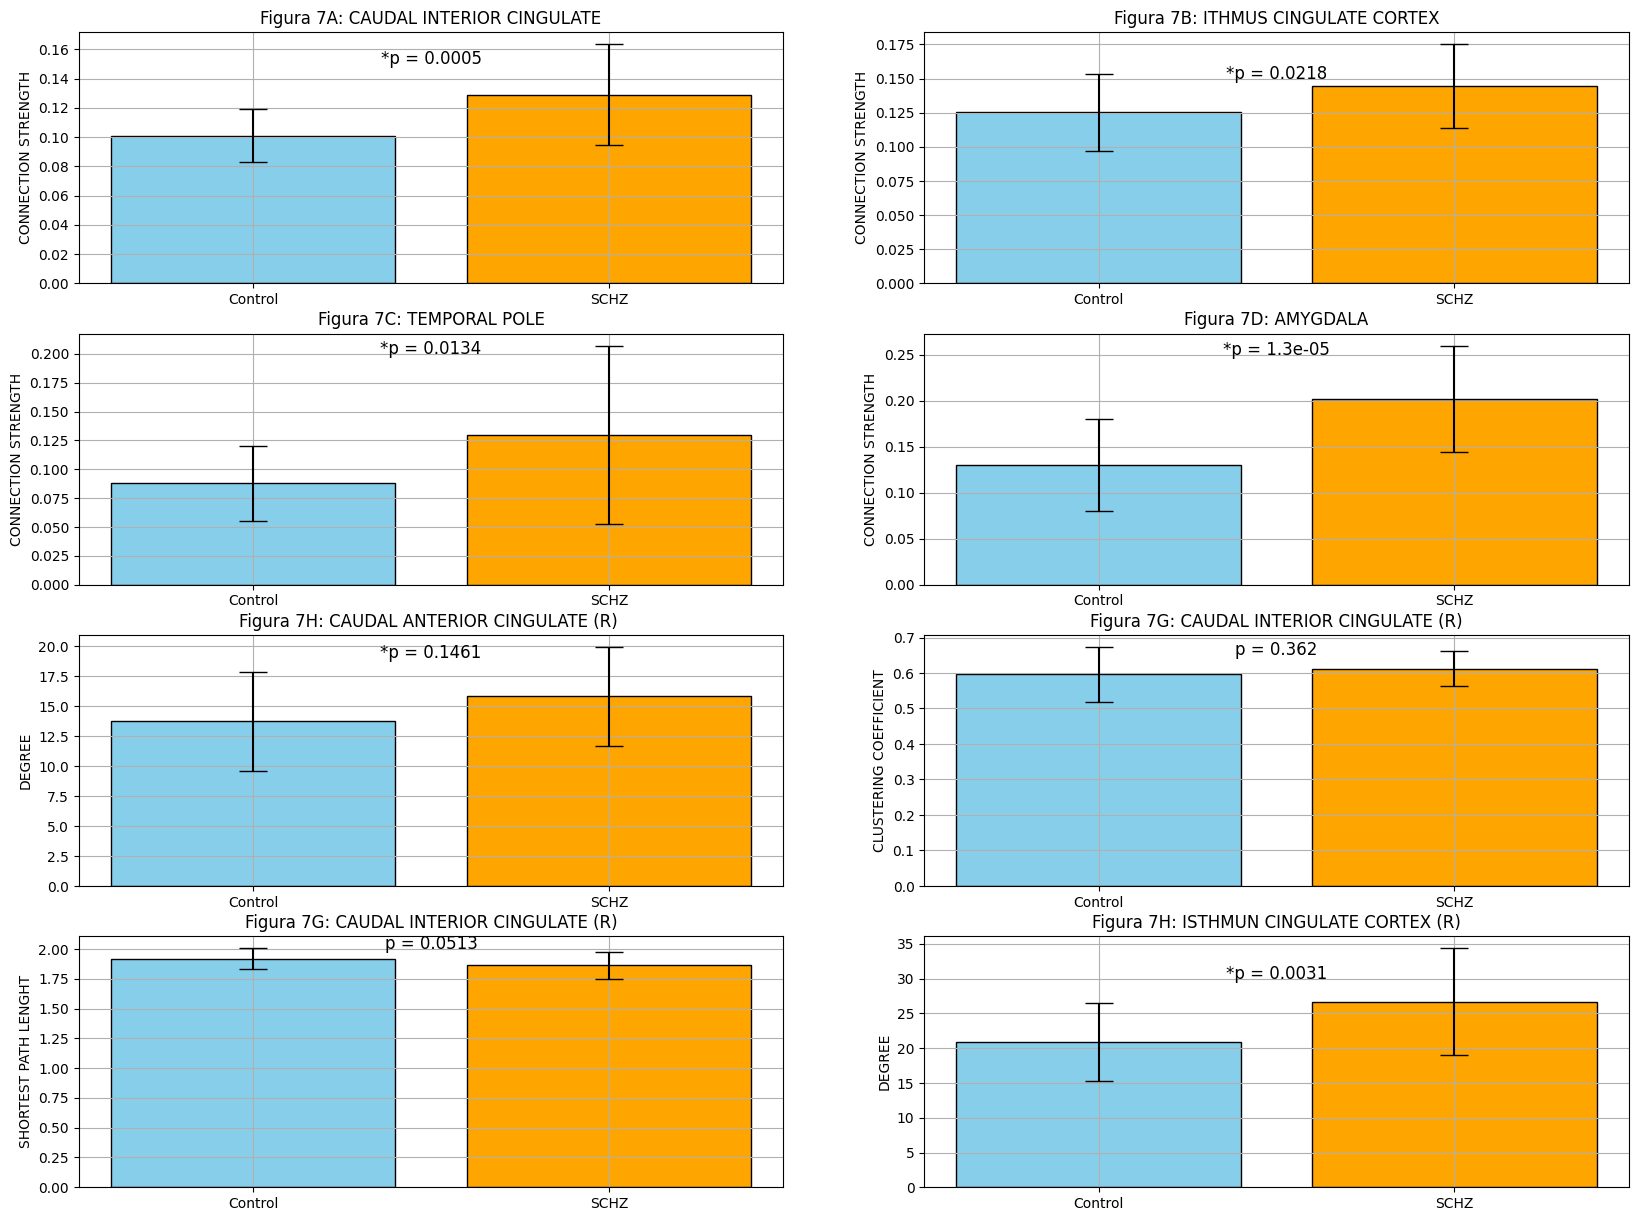

In [ ]:
#configuracion grafica

plt.figure(figsize=(20, 15))


plt.subplot(4, 2, 1)
plt.bar(['Control', 'SCHZ'], [mean_Cuadal_ctrl, mean_Cuadal_schizo ],yerr=[std_Cuadal_ctrl, std_Cuadal_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,0.15, f'*p = {round(p_val_cau, 4)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION STRENGTH')
plt.title('Figura 7A: CAUDAL INTERIOR CINGULATE')
plt.grid()

plt.subplot(4, 2, 2)
plt.bar(['Control', 'SCHZ'], [mean_cortex_ctrl , mean_cortex_shizo],yerr=[std_cortex_ctrl, std_cortex_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,0.15, f'*p = {round(p_val_i, 4)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION STRENGTH')
plt.title('Figura 7B: ITHMUS CINGULATE CORTEX')
plt.grid()

plt.subplot(4, 2, 3)
plt.bar(['Control', 'SCHZ'], [mean_temp_ctrl, mean_temp_schizo ],yerr=[ std_temp_ctrl, std_temp_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,0.2, f'*p = {round(p_val_ttt, 4)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION STRENGTH')
plt.title('Figura 7C: TEMPORAL POLE')
plt.grid()

plt.subplot(4, 2, 4)
plt.bar(['Control', 'SCHZ'], [mean_amig_ctrl, mean_amig_schizo],yerr=[ std_amig_ctrl, std_amig_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,0.25, f'*p = {round(p_val_yg, 6)}', ha='center', fontsize=12)
plt.ylabel('CONNECTION STRENGTH')
plt.title('Figura 7D: AMYGDALA')
plt.grid()

plt.subplot(4, 2, 5)
plt.bar(['Control', 'SCHZ'], [mean_deg_cau_ctrl, mean_deg_cau_schizo],yerr=[ std_deg_cau_ctrl, std_deg_cau_ctrl], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,19, f'*p = {round(p_val_cau_degree, 4)}', ha='center', fontsize=12)
plt.ylabel('DEGREE')
plt.title('Figura 7H: CAUDAL ANTERIOR CINGULATE (R) ')
plt.grid()


plt.subplot(4, 2, 6)
plt.bar(['Control', 'SCHZ'], [mean_clus_ctrl, mean_clus_schizo],yerr=[ std_clus_ctrl, std_clus_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,0.65, f'p = {round(p_val_cluster_cau, 4)}', ha='center', fontsize=12)
plt.ylabel('CLUSTERING COEFFICIENT')
plt.title('Figura 7G: CAUDAL INTERIOR CINGULATE (R)')
plt.grid()


plt.subplot(4, 2, 7)
plt.bar(['Control', 'SCHZ'], [short_mean_cau_ctrl, short_mean_cau_shizo],yerr=[ short_std_cau_ctrl, short_std_cau_shizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,2 ,f'p = {round(p_val_short_cau, 4)}', ha='center', fontsize=12)
plt.ylabel('SHORTEST PATH LENGHT')
plt.title('Figura 7G: CAUDAL INTERIOR CINGULATE (R)')
plt.grid()



plt.subplot(4, 2, 8)
plt.bar(['Control', 'SCHZ'], [mean_deg_iths_ctrl, mean_deg_iths_schizo],yerr=[ std_deg_iths_ctrl, std_deg_iths_schizo], capsize=10,edgecolor='black', color=['skyblue', 'orange'])
plt.text(0.5,30, f'*p = {round(p_val_iths_degree, 4)}', ha='center', fontsize=12)
plt.ylabel('DEGREE')
plt.title('Figura 7H: ISTHMUN CINGULATE CORTEX (R)')
plt.grid()

* Respecto a la distribución de las ondas cerebrales en el grupo control, se demuestra en este trabajo que las regiones con ondas beta pertenecen principalmente a la **red en modo por defecto (DMN)**, **la red sensoriomotora (SMN)** y la red de **los ganglios basales (BGN)**. La DMN incluye la corteza prefrontal medial ventral (vMPFC), la corteza prefrontal medial dorsal (dMPC), el cíngulo posterior, el precúneo y la corteza parietal lateral. Esta red está profundamente involucrada en funciones cognitivas superiores, como el procesamiento emocional y la autorreferencia mental. La SMN es una red activa en reposo que incluye las circunvoluciones precentral, postcentral y frontal medial, las cortezas sensoriomotoras primarias y el área motora suplementaria.

* el reforzamiento de la conectividad local en las redes estructurales es la causa de la anormalidad dinámica en estas regiones con transición a ondas beta.

* la anomalía dinámica en las cuatro regiones con transición de estados inciertos a beta está relacionada con cambios estructurales locales en dichas regiones

#REFERENCIAS:

---

[1] Baeldung, "Graph density - A complete guide," Baeldung on Computer Science. [Online]. Available: https://www.baeldung.com/cs/graph-density


[2] GeeksforGeeks. (n.d.). Clustering Coefficient in Graph Theory. GeeksforGeeks. https://www.geeksforgeeks.org/dsa/clustering-coefficient-graph-theory/

[3] Math Insight. (n.d.). Clustering coefficient. https://mathinsight.org/definition/clustering_coefficient

[4] NetworkX Developers. (n.d.). networkx.algorithms.cluster.average_clustering. NetworkX documentation. https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.cluster.average_clustering.html


[5] NetworkX Developers. (n.d.). networkx.algorithms.shortest_paths.generic.shortest_path_length — NetworkX documentation. https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path_length.html

[6] Sayama, H. (n.d.). 17.2: Shortest Path Length. In Introduction to the Modeling and Analysis of Complex Systems. LibreTexts. https://math.libretexts.org/Bookshelves/Scientific_Computing_Simulations_and_Modeling/Introduction_to_the_Modeling_and_Analysis_of_Complex_Systems_(Sayama)/17%3A_Dynamical_Networks_II__Analysis_of_Network_Topologies/17.02%3A_Shortest_Path_Length

[7] GeeksforGeeks. (n.d.). Betweenness Centrality - Centrality Measure. https://www.geeksforgeeks.org/dsa/betweenness-centrality-centrality-measure/

[8] NetworkX Developers. (n.d.). networkx.algorithms.efficiency_measures.global_efficiency. NetworkX. http://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.efficiency_measures.global_efficiency.html



